# Reinforcement Learning for Nuclear Outage Scheduling (ROADEF/EURO 2010)

This notebook reproduces the **analysis, figures and tables** comparing a
reinforcement-learning (RL) scheduler against integer programming on the
ROADEF/EURO 2010 EDF nuclear outage-scheduling problem (instances **data0–data2**).
It accompanies the report section *"A reinforcement learning approach."*

**Contents**
1. The instances and the demand (load) $L$.
2. The cost model and modelling assumptions — how a candidate schedule is scored.
3. The four methods: **Jost ILP** ($\lambda=0$), **CVaR-ILP** ($\lambda=0.7$), and
   **local-search RL** at $\lambda\in\{0,0.7\}$.
4. Results: the cost table, schedule overlays, the risk objective $J$, the
   cost-statistic distribution, and an all-method operational overlay.
5. Independent feasibility verification with the official ROADEF `checker.jar`.

> **Data note.** The large ROADEF instance files (`data_release_13102009/`) and the
> solution files (`sol*.txt`) are not committed to the repository (size / regenerated).
> The figures and tables here are therefore **pre-executed and embedded** so they
> render without the raw data. To re-run end-to-end, place the instances and
> `sol*.txt` solutions in the working directory and run all cells.

## 1&nbsp;&nbsp;Related work

The scheduling of nuclear maintenance and refuelling outages has traditionally been
addressed with exact and matheuristic optimisation. The ROADEF/EURO 2010 challenge
was won with a 0–1 integer-linear-programming decomposition (Jost & Savourey, 2013),
and the state of the art for the full multi-year instances uses mixed-integer
matheuristics combining constructive procedures with local search (Dupin & Talbi,
2021); the broader setting of large-scale generation scheduling under uncertainty
is surveyed by van Ackooij et&nbsp;al. (2018).

Reinforcement learning has, by contrast, been applied mainly to *adjacent* problems:
in-core fuel **loading-pattern** design (Seurin et&nbsp;al., 2023), and joint bidding /
maintenance scheduling in electricity markets (multi-agent deep RL). To our knowledge,
RL has not previously been applied to the coupled, long-horizon nuclear
refuelling-and-maintenance outage problem with fuel-stock dynamics and demand
uncertainty considered here. We therefore investigate RL as a learned,
uncertainty-aware **refinement** of an integer-programming seed.

## 2&nbsp;&nbsp;The problem as a Markov decision process

We recast outage scheduling as a sequential decision problem solved with deep RL,
formalised as an MDP $(\mathcal S,\mathcal A,P,R)$ with an undiscounted finite horizon
($\gamma=1$). Two design choices shape it:

1. **The agent decides only the outage schedule** — when each nuclear plant goes
   offline to refuel. It does *not* decide production: once the schedule is fixed,
   every plant's output at each time step and scenario is computed exactly by a
   cheapest-first dispatch. So each candidate schedule is scored at its **optimal**
   production cost, not a noisy estimate.
2. **The agent improves an existing schedule** rather than building one. It is
   seeded with a complete feasible schedule from the Jost ILP and repeatedly shifts
   outages to nearby weeks to lower the risk objective $J(\lambda)$. Every move
   preserves feasibility, and the best schedule seen is retained — so the result is
   **never worse than the seed**.

| element | definition |
|---|---|
| **State** $s_t$ | the current outage $(i,k)$ + global search progress, as a 14-D normalised vector |
| **Action** $a_t$ | relocate the current outage to a new start week (offsets / demand-aware jumps), masked to feasible targets |
| **Transition** $P$ | apply the move iff feasible (re-simulate CT3–CT12, re-check coupling CT14–CT21), re-dispatch, recompute the per-scenario cost vector $C$ over all $S$ scenarios |
| **Reward** $R$ | the reduction in $J(\lambda)$ produced by the move |

The policy is a neural network trained with **Maskable PPO**; the risk weight
$\lambda$ is one of its inputs, so a single policy serves every risk level.

**Observation (14 features).** plant id $i/30$; cycle $k/K$; window edges
$\mathrm{TO}/H,\mathrm{TA}/H$; position in window; duration $\mathrm{DA}/H$; current
& minimum weekly demand and their gap; fuel stock $x/\mathrm{SMAX}$; sweep progress;
$J/J_0$; and $\lambda$.

**Reward.** $r_t=(J_\text{before}-J_\text{after})/\eta$, $\eta=|J_\text{seed}|/10$;
summed over an episode the return telescopes to $(J_\text{seed}-J_\text{final})/\eta$,
so maximising return $\equiv$ minimising the final $J$.

## 3&nbsp;&nbsp;Cost model and modelling assumptions

The optimiser chooses **only** the outage schedule
$\mathrm{ha}(i,k)$ (the week cycle $k$ of plant $i$ goes offline). Given $\mathrm{ha}$,
everything else — reloads $r$, nuclear/thermal outputs $p$, fuel stocks $x$ — is
**determined**, under:

- **(A1) Reloads** fixed at $r(i,k)=\mathrm{RMAX}_{i,k}$ (or a feasibility search in
  $[\mathrm{RMIN},\mathrm{RMAX}]$); reloads are not cost-optimised.
- **(A2) Full-power nuclear policy**: online plants run at $\mathrm{PMAX}$ while stock
  $\ge \mathrm{BO}$, else follow a decreasing profile; $0$ on outage. Hence $p(i,t),x(i,t)$
  are deterministic and **scenario-independent**.
- **(A3) Merit-order dispatch**: thermal meets residual demand cheapest-first — the
  *exact* optimum of the production sub-problem.
- **(A4) Scenario structure**: only demand varies with $s$; nuclear is common to all $s$.

**Fuel balance (CT9) and policy (A2):**
$$x(i,t+1)=x(i,t)-p(i,t)\,D_t,\qquad
p(i,t)=\begin{cases}0,&\text{outage}\\ \mathrm{PMAX}^t_i,& x\ge \mathrm{BO}_{i,k}\\ \mathrm{PB}_{i,k}(x)\,\mathrm{PMAX}^t_i,& x<\mathrm{BO}_{i,k}\end{cases}$$

**Refuel jump (CT10):**
$$x^{+}(i,k)=\tfrac{Q_{i,k}-1}{Q_{i,k}}\bigl(x^{-}(i,k)-\mathrm{BO}_{i,k-1}\bigr)+r(i,k)+\mathrm{BO}_{i,k}.$$

**Thermal dispatch:** with residual $R_{t,s}=\mathrm{DEM}_{t,s}-\sum_i p(i,t)$,
$$\min \sum_j C_j(t,s)\,p(j,t,s)\quad\text{s.t.}\quad \sum_j p(j,t,s)=R_{t,s},\ 0\le p\le \mathrm{PMAX}.$$

**Per-scenario cost and objective:**
$$C_s=\underbrace{\textstyle\sum_{i,k} C_{i,k}\,r(i,k)}_{\text{refuel}}
+\underbrace{\textstyle\sum_{j,t} C_j(t,s)\,p(j,t,s)\,D_t}_{\text{thermal}}
-\underbrace{\textstyle\sum_i C_{i,T+1}\,x(i,T)}_{\text{end-fuel credit}},$$
$$\boxed{\,\min_{\mathrm{ha}}\ J_\lambda=(1-\lambda)\tfrac1S\textstyle\sum_s C_s+\lambda\,\mathrm{CVaR}_{0.8}(C)\,}$$
where $\mathrm{CVaR}_{0.8}$ is the mean of the worst $20\%$ of scenario costs.

## 4&nbsp;&nbsp;Setup

Import the project modules (the solver, the forward-simulation *engine*, the
merit-order dispatch oracle, and the plotting helpers in `rl_jost_figs`).

In [1]:
import os, sys, json, shutil, subprocess, tempfile, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")           # headless: every figure is saved and displayed via Image()
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = os.getcwd()
sys.path.insert(0, os.path.join(HERE, "solver_src"))
from solver import parse_instance
from engine import simulate_plant
from data1_solver import merit_dispatch
from rl_localsearch import parse_sol_schedule, per_scenario_cost, cvar as cvar_fn
from cvar_repair import feasible_reload
import rl_jost_figs as figs

def load(ds):
    return parse_instance(os.path.join(HERE, "data_release_13102009",
                                       "data_release_13102009", f"{ds}.txt"))
def show(path):
    display(Image(filename=path))

print("modules loaded — pandas", pd.__version__, "| matplotlib", matplotlib.__version__)

modules loaded — pandas 2.3.3 | matplotlib 3.10.7


## 5&nbsp;&nbsp;The instances and the load $L$

Each instance gives a demand (load) matrix $L = \mathrm{DEM}_{s,t}$ of **scenarios ×
time steps** in MW; the $S$ scenarios are the demand uncertainty. We list the three
instances and then export / plot data1's load.

In [2]:
DS_LIST = ["data0", "data1", "data2"]
INST = {ds: load(ds) for ds in DS_LIST}

info = []
for ds in DS_LIST:
    it = INST[ds]
    info.append(dict(instance=ds, nuclear_units=it["I"], thermal=it["J"],
                     scenarios=it["S"], weeks=it["H"], timesteps=it["T"],
                     step_hours=int(it["D"][0])))
pd.DataFrame(info).set_index("instance")

,nuclear_units,thermal,scenarios,weeks,timesteps,step_hours
instance,,,,,,
data0,2,1,2,89,623,24
data1,10,11,10,250,1750,24
data2,18,21,20,250,1750,24


data1 load: (10, 1750) (scenarios x timesteps), MW | mean 59459  peak 88043  min 26722
wrote data1_load.csv


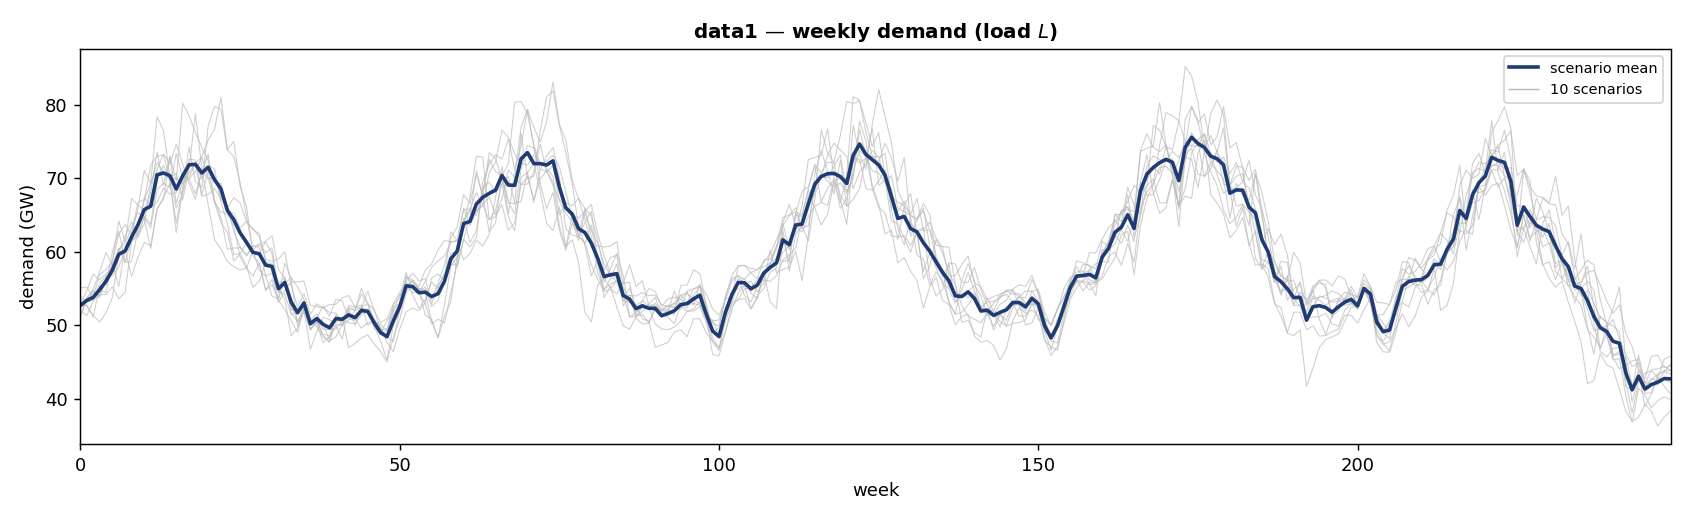

In [3]:
# data1 load: export to CSV (full per-timestep + weekly) and plot
inst = INST["data1"]; DEM = np.asarray(inst["DEM"]); tpw = inst["tpw"]; S, T = DEM.shape

import csv
with open("data1_load.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["timestep", "week", "duration_h"] + [f"demand_MW_s{s}" for s in range(S)])
    for t in range(T):
        w.writerow([t, t // tpw, inst["D"][t]] + [f"{DEM[s, t]:.2f}" for s in range(S)])

nW = T // tpw
wk_each = DEM[:, :nW * tpw].reshape(S, nW, tpw).mean(axis=2)
wk_mean = wk_each.mean(axis=0)
print(f"data1 load: {DEM.shape} (scenarios x timesteps), MW | "
      f"mean {DEM.mean():.0f}  peak {DEM.max():.0f}  min {DEM.min():.0f}")
print("wrote data1_load.csv")

fig, ax = plt.subplots(figsize=(13, 4))
for s in range(S):
    ax.plot(np.arange(nW), wk_each[s] / 1e3, color="#bbb", lw=0.6, alpha=0.7)
ax.plot(np.arange(nW), wk_mean / 1e3, color="#1f3b73", lw=2.0, label="scenario mean")
ax.plot([], [], color="#bbb", lw=0.8, label=f"{S} scenarios")
ax.set_xlabel("week"); ax.set_ylabel("demand (GW)"); ax.set_xlim(0, nW - 1)
ax.set_title("data1 — weekly demand (load $L$)", fontsize=11, weight="bold")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig("fig_load_data1.png", dpi=130); plt.close(fig)
show("fig_load_data1.png")

## 6&nbsp;&nbsp;Scoring a schedule (the cost oracle)

Helpers used throughout: load each method's schedule, forward-simulate the nuclear
fleet, run the merit-order dispatch, and read off the per-scenario cost vector $C$
and its statistics. On **data2** the Jost entry is the original team solution
(`sol2`) and the CVaR-ILP entry is its fuel-repaired schedule (both checker-feasible).

In [4]:
ORDER = ["Jost ILP (λ=0)", "CVaR-ILP (λ=0.7)", "RL (λ=0)", "RL (λ=0.7)"]
LAM   = {"Jost ILP (λ=0)": 0.0, "CVaR-ILP (λ=0.7)": 0.7, "RL (λ=0)": 0.0, "RL (λ=0.7)": 0.7}
FILES = {"Jost ILP (λ=0)": "sol_JostILP", "CVaR-ILP (λ=0.7)": "sol_CVARILP",
         "RL (λ=0)": "sol_RLls0", "RL (λ=0.7)": "sol_RLls70"}

def get_schedules(ds):
    inst = INST[ds]; out = {}
    if ds == "data2":
        out["Jost ILP (λ=0)"] = parse_sol_schedule("sol2.txt", inst)
        crep = {int(k): v for k, v in json.load(open("cvar_repaired_sched_data2.json")).items()}
        cr = {p["index"]: feasible_reload(p, inst, crep[p["index"]], inst["eps"]) for p in inst["type2"]}
        out["CVaR-ILP (λ=0.7)"] = (crep, cr)
        for m in ["RL (λ=0)", "RL (λ=0.7)"]:
            out[m] = parse_sol_schedule(f"{FILES[m]}_{ds}.txt", inst)
    else:
        for m in ORDER:
            p = f"{FILES[m]}_{ds}.txt"
            if os.path.exists(p):
                out[m] = parse_sol_schedule(p, inst)
    return out

def simulate(inst, schedule, reloads):
    sims = {}
    for p in inst["type2"]:
        i = p["index"]
        prod, x, fe, _ = simulate_plant(p, inst, schedule[i], reloads[i], inst["eps"])
        sims[i] = (prod, x)
    cost_s, p1, _ = per_scenario_cost(inst, schedule, reloads, sims)
    return sims, p1, np.asarray(cost_s, float)

def stats_of(c):
    return dict(mean=float(c.mean()), cvar=float(cvar_fn(c, 0.8)),
                worst=float(c.max()), std=float(c.std()))
def Jval(mean, cv, lam):
    return (1 - lam) * mean + lam * cv

# schedules + summary statistics for every method on every instance (computed once)
SCHED, SUMMARY = {}, {}
for ds in DS_LIST:
    SCHED[ds] = get_schedules(ds); SUMMARY[ds] = {}
    for m, (s, r) in SCHED[ds].items():
        _, _, c = simulate(INST[ds], s, r)
        st = stats_of(c); st["lam"] = LAM[m]; st["J"] = Jval(st["mean"], st["cvar"], LAM[m])
        SUMMARY[ds][m] = st
print("scored:", {ds: list(SUMMARY[ds]) for ds in DS_LIST})

scored: {'data0': ['Jost ILP (λ=0)', 'CVaR-ILP (λ=0.7)', 'RL (λ=0)', 'RL (λ=0.7)'], 'data1': ['Jost ILP (λ=0)', 'CVaR-ILP (λ=0.7)', 'RL (λ=0)', 'RL (λ=0.7)'], 'data2': ['Jost ILP (λ=0)', 'CVaR-ILP (λ=0.7)', 'RL (λ=0)', 'RL (λ=0.7)']}


In [5]:
# demonstrate the oracle on the data1 Jost seed
inst = INST["data1"]; sched, reloads = SCHED["data1"]["Jost ILP (λ=0)"]
sims, p1, cost_s = simulate(inst, sched, reloads)
st = stats_of(cost_s)
print("thermal dispatch p1 shape [J, S, T] :", p1.shape)
print("per-scenario cost C_s (first 5)     :", np.round(cost_s[:5] / 1e9, 2), "(×1e9)")
print(f"mean C = {st['mean']:.4e}   CVaR_0.8 = {st['cvar']:.4e}   worst = {st['worst']:.4e}")
print(f"J(λ=0) = {Jval(st['mean'], st['cvar'], 0.0):.4e}    J(λ=0.7) = {Jval(st['mean'], st['cvar'], 0.7):.4e}")

thermal dispatch p1 shape [J, S, T] : (11, 10, 1750)
per-scenario cost C_s (first 5)     : [174.34 168.85 166.6  154.16 214.3 ] (×1e9)
mean C = 1.7178e+11   CVaR_0.8 = 1.9984e+11   worst = 2.1430e+11
J(λ=0) = 1.7178e+11    J(λ=0.7) = 1.9142e+11


## 7&nbsp;&nbsp;The deep-RL method (Maskable PPO local search)

This is the actual **deep-learning** component. The agent is a **Maskable PPO**
policy (`sb3_contrib`) with an `MlpPolicy`, trained on the `RoadefLocalSearchEnv`
gym environment ([`rl_localsearch.py`](rl_localsearch.py)) by the loop in
[`train_localsearch.py`](train_localsearch.py). It starts from a feasible seed
schedule and repeatedly relocates outages; an **action mask** blocks every
infeasible move and the **reward** is the per-move reduction in $J$, so maximising
return $\equiv$ minimising $J$. One network serves every risk level because
$\lambda$ is one of its 14 inputs.

Below we (a) inspect the environment, (b) **train a policy live** on the tiny data0,
and (c) **load the pre-trained data2 policy** and roll it out to show the real
improvement over the seed.

In [6]:
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker
from rl_localsearch import RoadefLocalSearchEnv, rollout_localsearch

# (a) the environment: 14-D observation, discrete masked action set
inst0 = INST["data0"]; seed0_s, seed0_r = parse_sol_schedule("sol0.txt", inst0)
env = RoadefLocalSearchEnv(inst0, seed0_s, seed0_r, lam=0.7, n_sweeps=3)
env.reset()
print("observation dim :", env.obs_dim, "(normalised features incl. λ)")
print("action space    :", env.n_actions, "discrete moves (week offsets + demand-aware jumps)")
print("decision items  :", env.n_items, "scheduled outages to reposition")
print("action mask now :", env.action_masks().astype(int), " (1 = feasible move)")

observation dim : 14 (normalised features incl. λ)
action space    : 13 discrete moves (week offsets + demand-aware jumps)
decision items  : 4 scheduled outages to reposition
action mask now : [1 0 0 0 0 0 0 0 0 0 0 0 0]  (1 = feasible move)


In [7]:
# (b) TRAIN a Maskable PPO policy live on data0 (small, ~seconds)
venv = ActionMasker(RoadefLocalSearchEnv(inst0, seed0_s, seed0_r, lam=0.7, n_sweeps=3),
                    lambda e: e.action_masks())
t0 = time.time()
model = MaskablePPO("MlpPolicy", venv, seed=0, verbose=0, n_steps=512, batch_size=128,
                    gamma=0.99, ent_coef=0.01, learning_rate=3e-4)
model.learn(400)
ev = RoadefLocalSearchEnv(inst0, seed0_s, seed0_r, lam=0.7, n_sweeps=3)
snap = rollout_localsearch(ev, model, deterministic=True)
print(f"trained 400 steps in {time.time()-t0:.1f}s")
print(f"data0:  seed J = {ev.J0:.4e}   ->   RL J = {snap['J']:.4e}   ({100*(ev.J0-snap['J'])/ev.J0:+.2f}%)")
print("data0's 4-outage seed is already optimal, so RL correctly returns it — the")
print("best-so-far rule guarantees the result is never worse than the seed.")

trained 400 steps in 5.9s
data0:  seed J = 8.8185e+12   ->   RL J = 8.8185e+12   (+0.00%)
data0's 4-outage seed is already optimal, so RL correctly returns it — the
best-so-far rule guarantees the result is never worse than the seed.


In [8]:
# (c) the PAYOFF: load the policies trained on data2 (in train_localsearch.py) and roll out.
#     The .zip models are produced by full training; here we just run them.
inst2 = INST["data2"]; s2, r2 = parse_sol_schedule("sol2.txt", inst2)
rl_rows = []
for lam, mf in [(0.0, "ls_model_data2_lam0.zip"), (0.7, "ls_model_data2_lam70.zip")]:
    if not os.path.exists(mf):
        print("missing", mf, "(trained model not present locally) — skipping"); continue
    pol = MaskablePPO.load(mf)
    e = RoadefLocalSearchEnv(inst2, s2, r2, lam=lam, n_sweeps=3)
    sn = rollout_localsearch(e, pol, deterministic=True)
    rl_rows.append({"model": mf, "λ": lam, "seed_J": e.J0, "RL_J": sn["J"],
                    "reduction": f"{100*(e.J0-sn['J'])/e.J0:.2f}%"})
disp = pd.DataFrame(rl_rows)
if len(disp):
    for c in ["seed_J", "RL_J"]:
        disp[c] = disp[c].map(lambda v: f"{v:.4e}")
disp

,model,λ,seed_J,RL_J,reduction
0,ls_model_data2_lam0.zip,0.0,1.5310e+11,1.5214e+11,0.63%
1,ls_model_data2_lam70.zip,0.7,1.6836e+11,1.6360e+11,2.82%


## 8&nbsp;&nbsp;The integer programs (Jost ILP and CVaR MILP)

The two benchmarks, both built with **PuLP + CBC**:

- **Jost ILP** (`solve_jost_ilp` in [`rl_jost_dev.py`](rl_jost_dev.py)): the 0–1 first
  stage — binary outage-start variables $x_{i,k,h}$ over the CT13 windows, with cycle
  ordering and the coupling constraints CT14–CT21, maximising nuclear availability
  (the risk-neutral baseline, $\lambda=0$).
- **CVaR MILP** (`solve_cvar_ilp` in [`cvar_ilp.py`](cvar_ilp.py)): the same first stage
  plus an explicit extensive-form recourse (a weekly thermal dispatch $p_{j,w,s}$ per
  scenario) and a Rockafellar–Uryasev CVaR term, minimising
  $(1-\lambda)\overline C+\lambda\,\mathrm{CVaR}_{0.8}$ ($\lambda=0.7$).

We solve both **live on data0** here; the full data2 solves are recorded in
`round1_jost.json` / `round2_cvar.json`.

In [9]:
# Jost ILP (binary first stage) on data0
import rl_jost_dev as D
inst0 = INST["data0"]
t0 = time.time()
sch, status, _ = D.solve_jost_ilp(inst0, msg=False, time_limit=60)
jsched, jrl, jsims, jp1, jobj, jcost_s, jfeas, jbad = D.finalize_schedule(inst0, sch)
print(f"Jost ILP (data0): status={status}, feasible={jfeas}  ({time.time()-t0:.1f}s)")
print("chosen outage weeks  ha(i,k):", {i: list(sch[i]) for i in sorted(sch)})
print(f"mean cost = {np.mean(jcost_s):.4e}")

Jost ILP (data0): status=Optimal, feasible=True  (0.2s)
chosen outage weeks  ha(i,k): {0: [21, 56], 1: [32, 87]}
mean cost = 8.7413e+12


In [10]:
# CVaR-augmented extensive-form MILP (Rockafellar-Uryasev) on data0
import cvar_ilp
t0 = time.time()
r = cvar_ilp.solve_cvar_ilp(inst0, lam=0.7, alpha=0.8, time_limit=60, msg=False)
print(f"CVaR MILP (data0): status={r['status']}  ({time.time()-t0:.1f}s)")
print(f"  binary vars = {r['n_bin']},  continuous (recourse) vars = {r['n_cont']},  constraints = {r['n_con']}")
print(f"  ILP objective (1-lam)*mean + lam*CVaR_0.8 = {r['obj']:.4e}")
if r.get("schedule"):
    print("  chosen outage weeks:", {i: list(v) for i, v in sorted(r['schedule'].items())})

CVaR MILP (data0): status=optimal (0s)  (0.1s)
  binary vars = 36,  continuous (recourse) vars = 359,  constraints = 328
  ILP objective (1-lam)*mean + lam*CVaR_0.8 = 5.2481e+12
  chosen outage weeks: {0: [20, 56], 1: [32, 87]}


## 9&nbsp;&nbsp;Results table

All methods scored on the same oracle over all $S$ scenarios: mean,
$\mathrm{CVaR}_{0.8}$, worst case and standard deviation. (data2 ILP rows are the
team `sol2` and its fuel-repaired CVaR schedule; all four are checker-feasible.)

In [11]:
rows = []
for ds in DS_LIST:
    for m in ORDER:
        if m in SUMMARY[ds]:
            s = SUMMARY[ds][m]
            rows.append(dict(instance=ds, method=m.split(" (")[0], lam=s["lam"],
                             feasible="yes", mean=s["mean"], CVaR_0_8=s["cvar"],
                             worst=s["worst"], std=s["std"]))
df = pd.DataFrame(rows)
disp = df.copy()
for c in ["mean", "CVaR_0_8", "worst", "std"]:
    disp[c] = disp[c].map(lambda v: f"{v:.3e}")
disp.set_index(["instance", "method"])

lam feasible       mean   CVaR_0_8      worst        std
instance method                                                            
data0    Jost ILP  0.0      yes  8.741e+12  8.860e+12  8.860e+12  1.184e+11
         CVaR-ILP  0.7      yes  8.741e+12  8.859e+12  8.859e+12  1.184e+11
         RL        0.0      yes  8.736e+12  8.854e+12  8.854e+12  1.184e+11
         RL        0.7      yes  8.736e+12  8.854e+12  8.854e+12  1.184e+11
data1    Jost ILP  0.0      yes  1.718e+11  1.998e+11  2.143e+11  1.730e+10
         CVaR-ILP  0.7      yes  1.716e+11  1.996e+11  2.140e+11  1.726e+10
         RL        0.0      yes  1.722e+11  2.005e+11  2.155e+11  1.758e+10
         RL        0.7      yes  1.721e+11  2.002e+11  2.144e+11  1.726e+10
data2    Jost ILP  0.0      yes  1.531e+11  1.749e+11  1.850e+11  1.323e+10
         CVaR-ILP  0.7      yes  1.516e+11  1.693e+11  1.740e+11  1.111e+10
         RL        0.0      yes  1.521e+11  1.725e+11  1.823e+11  1.253e+10
         RL        0.7      yes  1.507e+11  1.691e+11  1.755e+11  1.152e+10

## 10&nbsp;&nbsp;Schedule overlays

For each instance, the outage week each method assigns to every nuclear unit, inside
its allowed CT13 window (grey band), with a side bar ranking the methods by mean cost
(% above the cheapest).

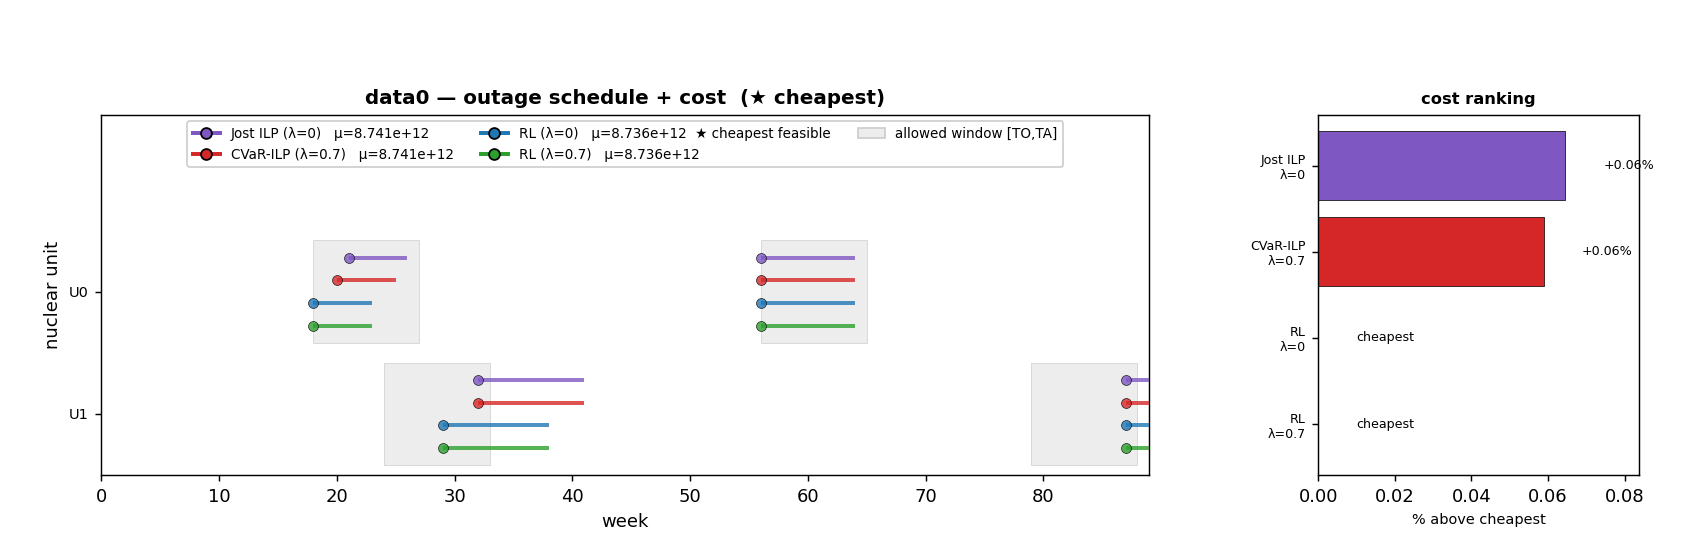

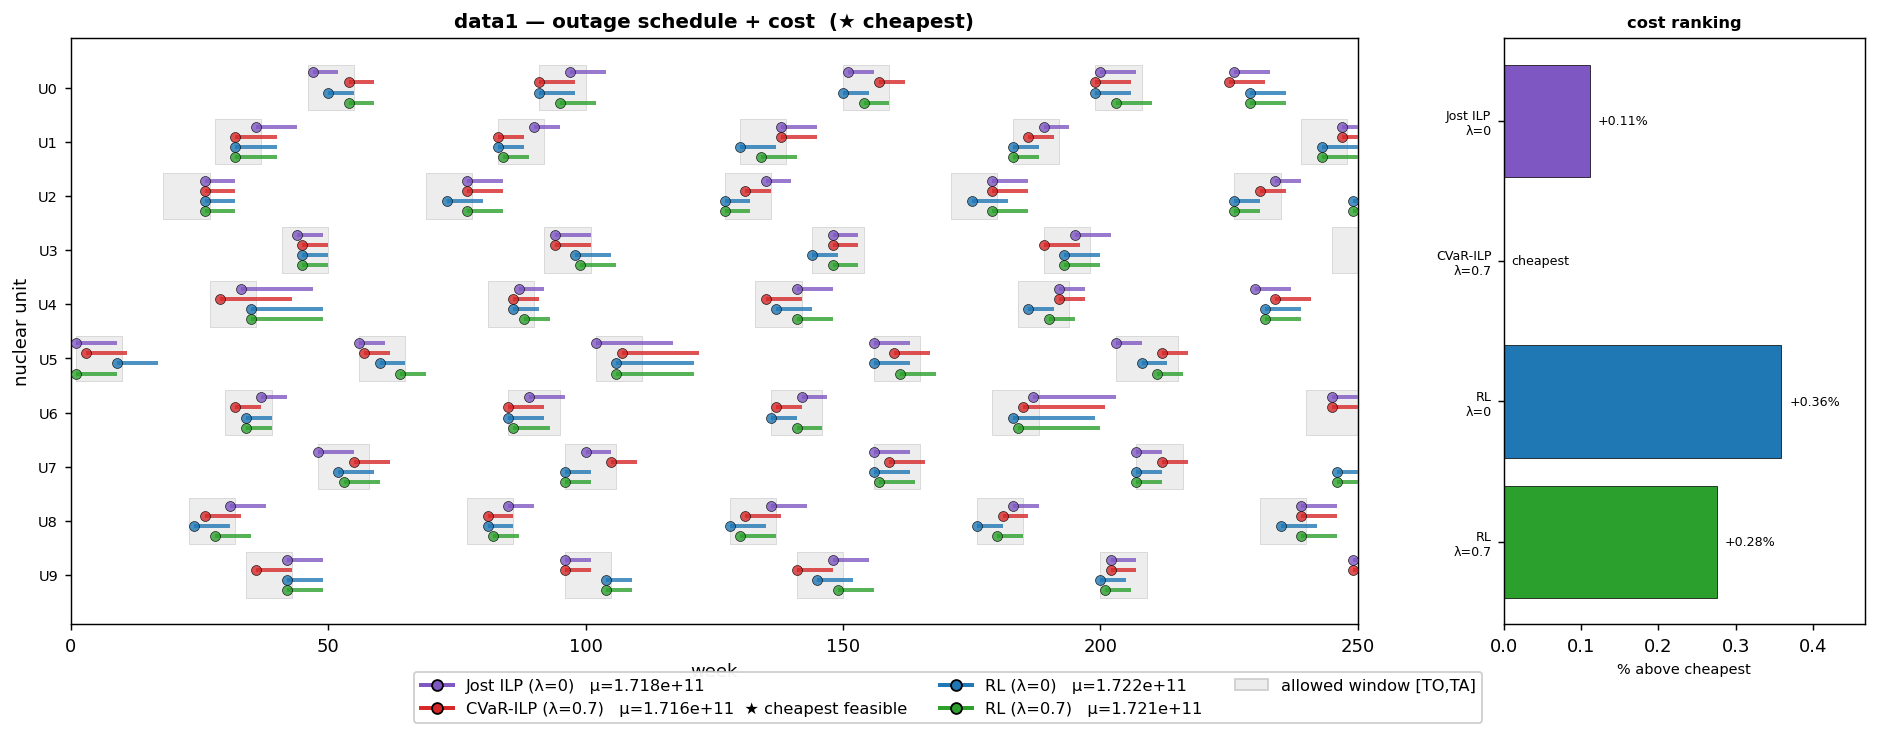

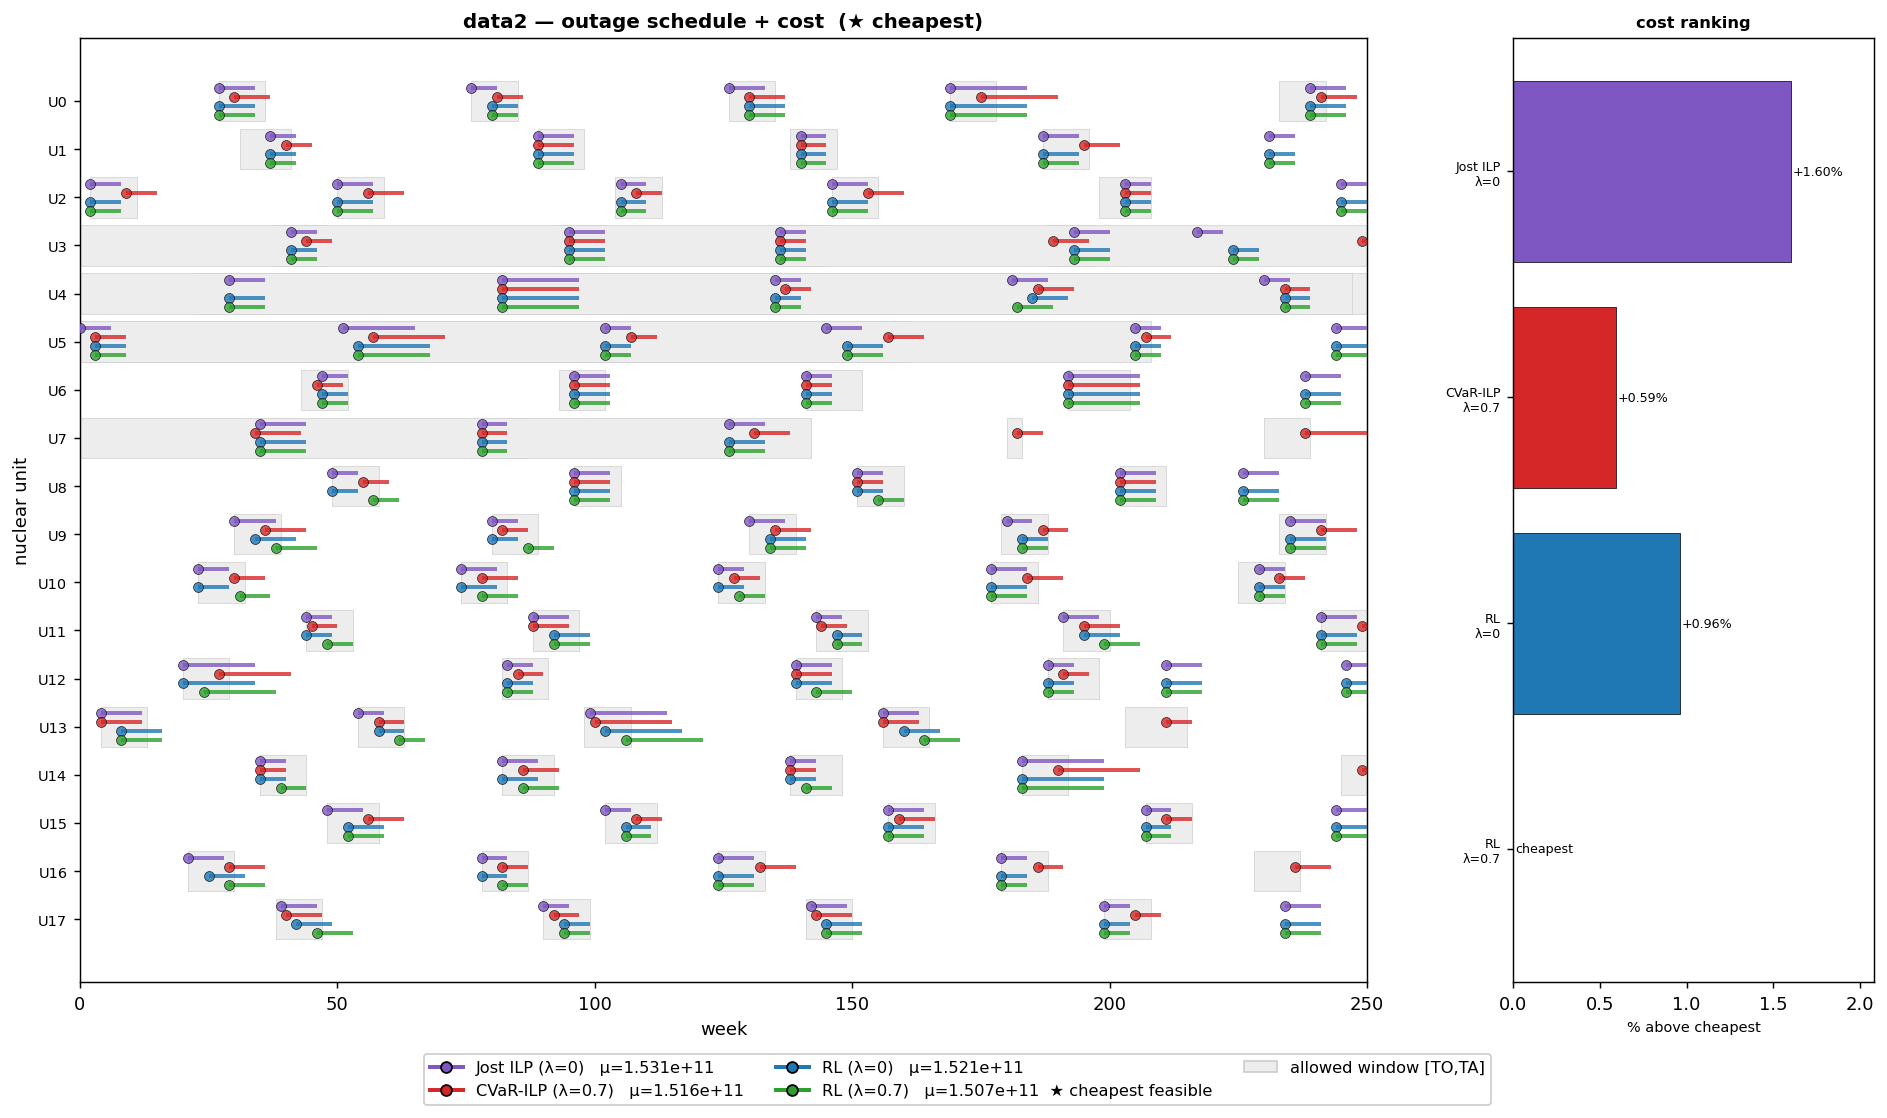

In [12]:
def sched_overlay(ds):
    inst = INST[ds]; present = [m for m in ORDER if m in SCHED[ds]]
    cost = {m: SUMMARY[ds][m]["mean"] for m in present}
    feas = {m: True for m in present}
    nunits = len(inst["type2"])

    if ds == "data0":                     # short instance: taller canvas, legend in a top band
        fig = plt.figure(figsize=(13, 4.2))
        axg = fig.add_axes([0.06, 0.13, 0.62, 0.66]); axc = fig.add_axes([0.78, 0.13, 0.19, 0.66])
    else:                                 # wide gantts: legend lifted out below the figure
        fig = plt.figure(figsize=(15, 1.3 + 0.42 * nunits))
        axg = fig.add_axes([0.05, 0.10, 0.66, 0.82]); axc = fig.add_axes([0.785, 0.10, 0.185, 0.82])

    figs.schedule_overlay(axg, inst, {m: SCHED[ds][m][0] for m in present},
        title=f"{ds} — outage schedule + cost  (★ cheapest)",
        cost_by_method=cost, feasible_by_method=feas)
    leg = axg.get_legend(); handles = list(leg.legend_handles)
    labels = [t.get_text() for t in leg.get_texts()]; leg.remove()
    if ds == "data0":
        axg.set_ylim(nunits - 0.5, -1.45)
        axg.legend(handles, labels, fontsize=7.5, loc="upper center", ncol=3,
                   framealpha=0.92, bbox_to_anchor=(0.5, 1.0))
        tight = False
    else:
        fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=9,
                   framealpha=0.95, bbox_to_anchor=(0.5, 0.045))
        tight = True

    best = min(cost.values()); y = np.arange(len(present))
    vals = [(cost[m] / best - 1) * 100 for m in present]
    axc.barh(y, vals, color=[figs.METHOD_PAL[m] for m in present], edgecolor="k", linewidth=0.4)
    for yi, m in enumerate(present):
        axc.text(max(vals[yi], 0) + 0.01, yi, "cheapest" if abs(vals[yi]) < 1e-9 else f"+{vals[yi]:.2f}%",
                 fontsize=7, va="center")
    axc.set_yticks(y); axc.set_yticklabels([m.replace(" (", "\n").replace(")", "") for m in present], fontsize=7)
    axc.invert_yaxis(); axc.set_xlabel("% above cheapest", fontsize=8)
    axc.set_title("cost ranking", fontsize=9, weight="bold"); axc.margins(x=0.3)
    path = f"fig_sched_overlay_{ds}.png"
    fig.savefig(path, dpi=130, **({"bbox_inches": "tight"} if tight else {}))
    plt.close(fig); return path

for ds in DS_LIST:
    show(sched_overlay(ds))

## 11&nbsp;&nbsp;Risk objective $J$

The objective each method actually optimises,
$J=(1-\lambda)\overline C+\lambda\,\mathrm{CVaR}_{0.8}$, at **each method's own $\lambda$**.
Methods are grouped by $\lambda$ (so RL is compared head-to-head with the ILP at the
same risk level) and the better of each pair is starred.

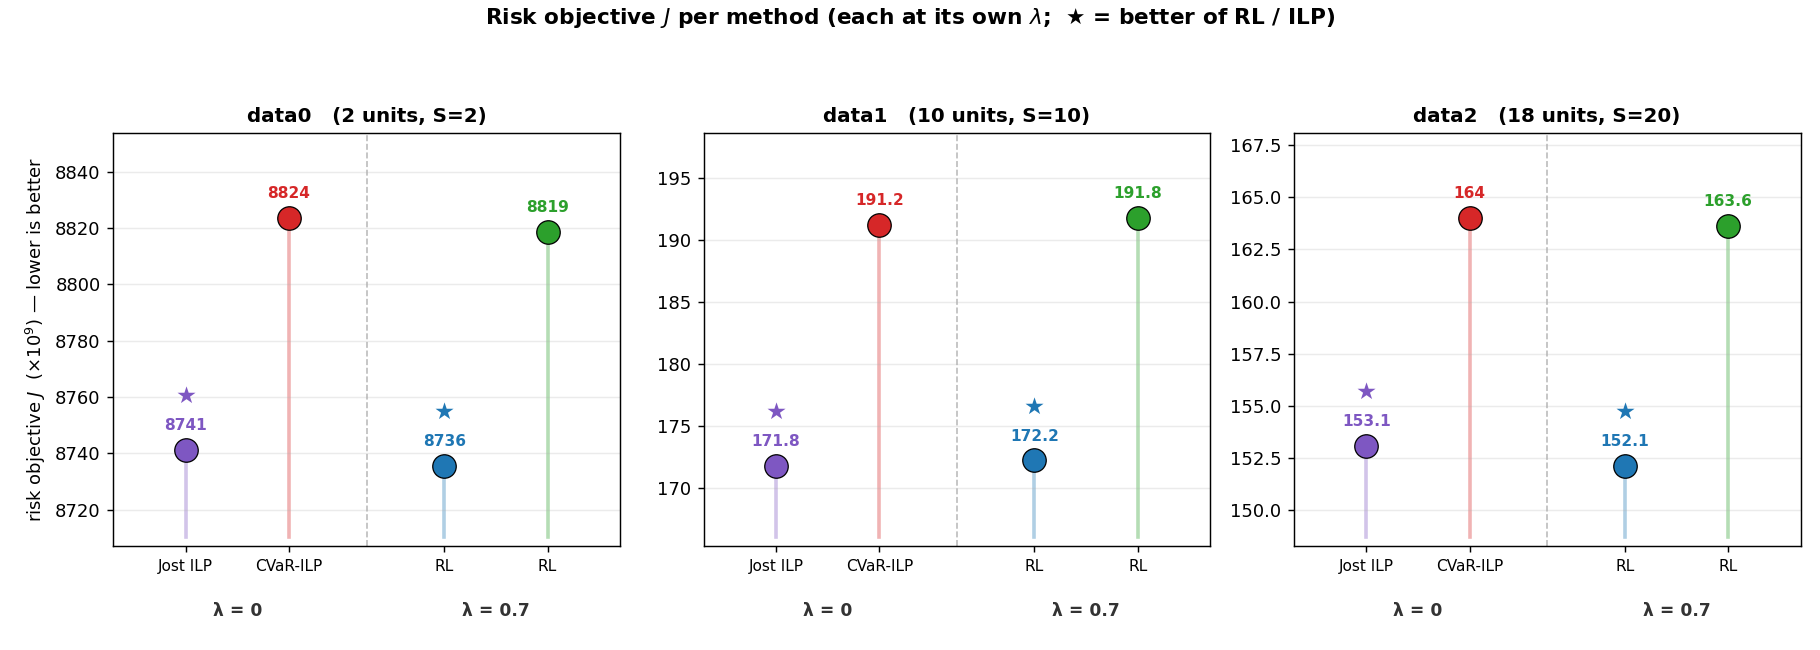

In [13]:
XPOS = [0.0, 1.0, 2.5, 3.5]; GROUPS = [(0.5, "λ = 0"), (3.0, "λ = 0.7")]
COL = {"Jost ILP (λ=0)": "#7e57c2", "CVaR-ILP (λ=0.7)": "#d62728",
       "RL (λ=0)": "#1f77b4", "RL (λ=0.7)": "#2ca02c"}
INFO = {"data0": "2 units, S=2", "data1": "10 units, S=10", "data2": "18 units, S=20"}
SCALE = 1e9

fig, axes = plt.subplots(1, 3, figsize=(14, 5.0))
for ax, ds in zip(axes, DS_LIST):
    rows = [(m, COL[m], SUMMARY[ds][m]["J"] / SCALE) for m in ORDER]
    Js = [r[2] for r in rows]
    win = {0 if Js[0] <= Js[1] else 1, 2 if Js[2] <= Js[3] else 3}
    lo, hi = min(Js), max(Js); pad = (hi - lo) * 0.18 + 1e-9
    base = lo - pad * 1.6; top = hi + pad * 1.9
    for idx, (xi, (m, col, Jv)) in enumerate(zip(XPOS, rows)):
        ax.plot([xi, xi], [base, Jv], color=col, lw=2.0, alpha=0.35, zorder=1)
        ax.plot([xi], [Jv], marker="o", ms=13, mfc=col, mec="k", mew=0.7, zorder=4)
        ax.annotate(f"{Jv:.4g}", (xi, Jv), textcoords="offset points", xytext=(0, 11),
                    ha="center", fontsize=8.5, color=col, weight="bold")
        if idx in win:
            ax.annotate("★", (xi, Jv), textcoords="offset points", xytext=(0, 26),
                        ha="center", fontsize=13, color=col)
    ax.axvline(1.75, color="#bbb", ls="--", lw=0.9, zorder=0)
    ax.set_xticks(XPOS); ax.set_xticklabels([m.split(" (")[0] for m in ORDER], fontsize=8.5)
    for gx, gl in GROUPS:
        ax.text(gx, -0.135, gl, transform=ax.get_xaxis_transform(), ha="center", va="top",
                fontsize=9.5, weight="bold", color="#333")
    ax.set_xlim(-0.7, 4.2); ax.set_ylim(base - pad * 0.2, top)
    ax.set_title(f"{ds}   ({INFO[ds]})", fontsize=11, weight="bold"); ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel(r"risk objective $J$  ($\times 10^{9}$) — lower is better", fontsize=10)
fig.suptitle(r"Risk objective $J$ per method (each at its own $\lambda$;  ★ = better of RL / ILP)",
             fontsize=12, weight="bold", y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94]); fig.savefig("fig_results_J.png", dpi=130); plt.close(fig)
show("fig_results_J.png")

## 12&nbsp;&nbsp;Cost-statistic distribution (lollipop)

The full row of the table as one glyph per method: dot = mean, grey bar = $\pm1$ std,
diamond = $\mathrm{CVaR}_{0.8}$, coloured stick + cap = spread up to the worst case.

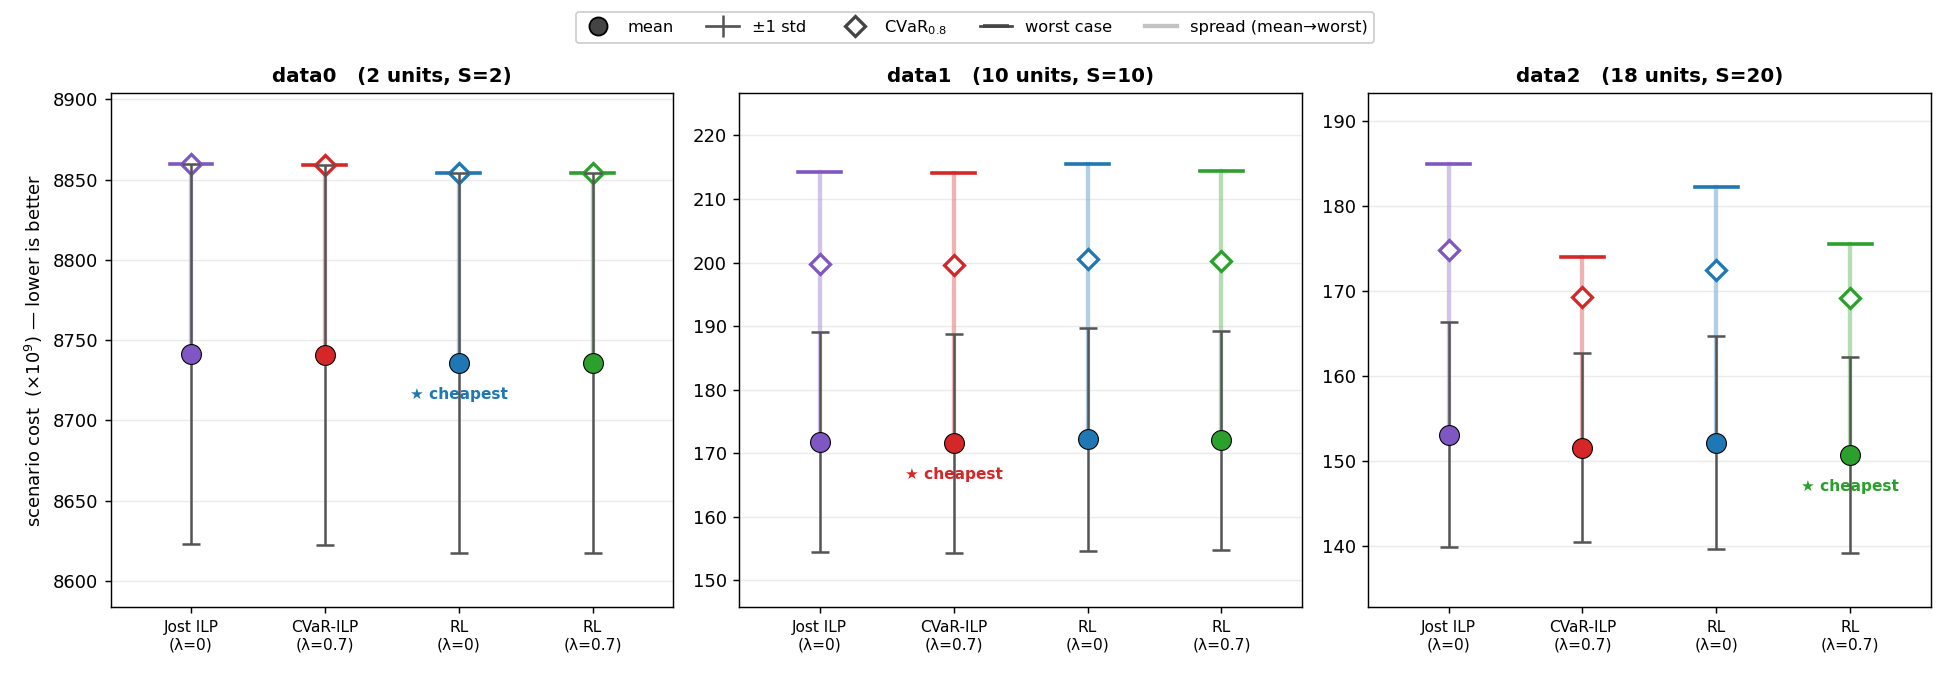

In [14]:
from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))
x = np.arange(len(ORDER))
for ax, ds in zip(axes, DS_LIST):
    rows = [SUMMARY[ds][m] for m in ORDER]
    means = [r["mean"] for r in rows]; best = int(np.argmin(means))
    for xi, (r, m) in enumerate(zip(rows, ORDER)):
        col = COL[m]; mn, cv, wo, sd = (r["mean"] / SCALE, r["cvar"] / SCALE,
                                        r["worst"] / SCALE, r["std"] / SCALE)
        ax.plot([xi, xi], [mn, wo], color=col, lw=2.4, alpha=0.35, zorder=1)
        ax.plot([xi - 0.16, xi + 0.16], [wo, wo], color=col, lw=2.0, zorder=3)
        ax.plot([xi], [cv], marker="D", ms=8, mfc="white", mec=col, mew=1.8, zorder=4)
        ax.errorbar([xi], [mn], yerr=[sd], fmt="none", ecolor="#555", elinewidth=1.4,
                    capsize=5, capthick=1.4, zorder=4)
        ax.plot([xi], [mn], marker="o", ms=11, mfc=col, mec="k", mew=0.6, zorder=5)
        if xi == best:
            ax.annotate("★ cheapest", (xi, mn), textcoords="offset points", xytext=(0, -20),
                        ha="center", fontsize=8.5, color=col, weight="bold")
    ax.set_xticks(x); ax.set_xticklabels([m.replace(" (", "\n(") for m in ORDER], fontsize=8.5)
    ax.set_xlim(-0.6, len(ORDER) - 0.4)
    lo = min(min(r["mean"] - r["std"] for r in rows), min(r["mean"] for r in rows)) / SCALE
    hi = max(r["worst"] for r in rows) / SCALE; pad = (hi - lo) * 0.14 + 1e-9
    ax.set_ylim(lo - pad, hi + pad * 1.3)
    ax.set_title(f"{ds}   ({INFO[ds]})", fontsize=11, weight="bold"); ax.grid(axis="y", alpha=0.25)
axes[0].set_ylabel(r"scenario cost  ($\times 10^{9}$) — lower is better", fontsize=10)
glyphs = [Line2D([0], [0], marker="o", color="w", mfc="#444", mec="k", ms=10, label="mean"),
          Line2D([0], [0], marker="|", color="#555", ms=12, mew=1.4, label="±1 std"),
          Line2D([0], [0], marker="D", color="w", mfc="white", mec="#444", mew=1.8, ms=8, label="CVaR$_{0.8}$"),
          Line2D([0], [0], marker="_", color="#444", ms=14, mew=2.0, label="worst case"),
          Line2D([0], [0], color="#888", lw=2.4, alpha=0.5, label="spread (mean→worst)")]
fig.legend(handles=glyphs, loc="upper center", ncol=5, fontsize=9, framealpha=0.92, bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=[0, 0, 1, 0.93]); fig.savefig("fig_results_lollipop.png", dpi=130); plt.close(fig)
show("fig_results_lollipop.png")

## 13&nbsp;&nbsp;All-method operational overlay

Tracing the four schedules through the quantities they drive: total nuclear and
thermal output, a representative unit's fuel sawtooth, and the **cumulative cost gap**
above the cheapest method (so small divergences are visible).

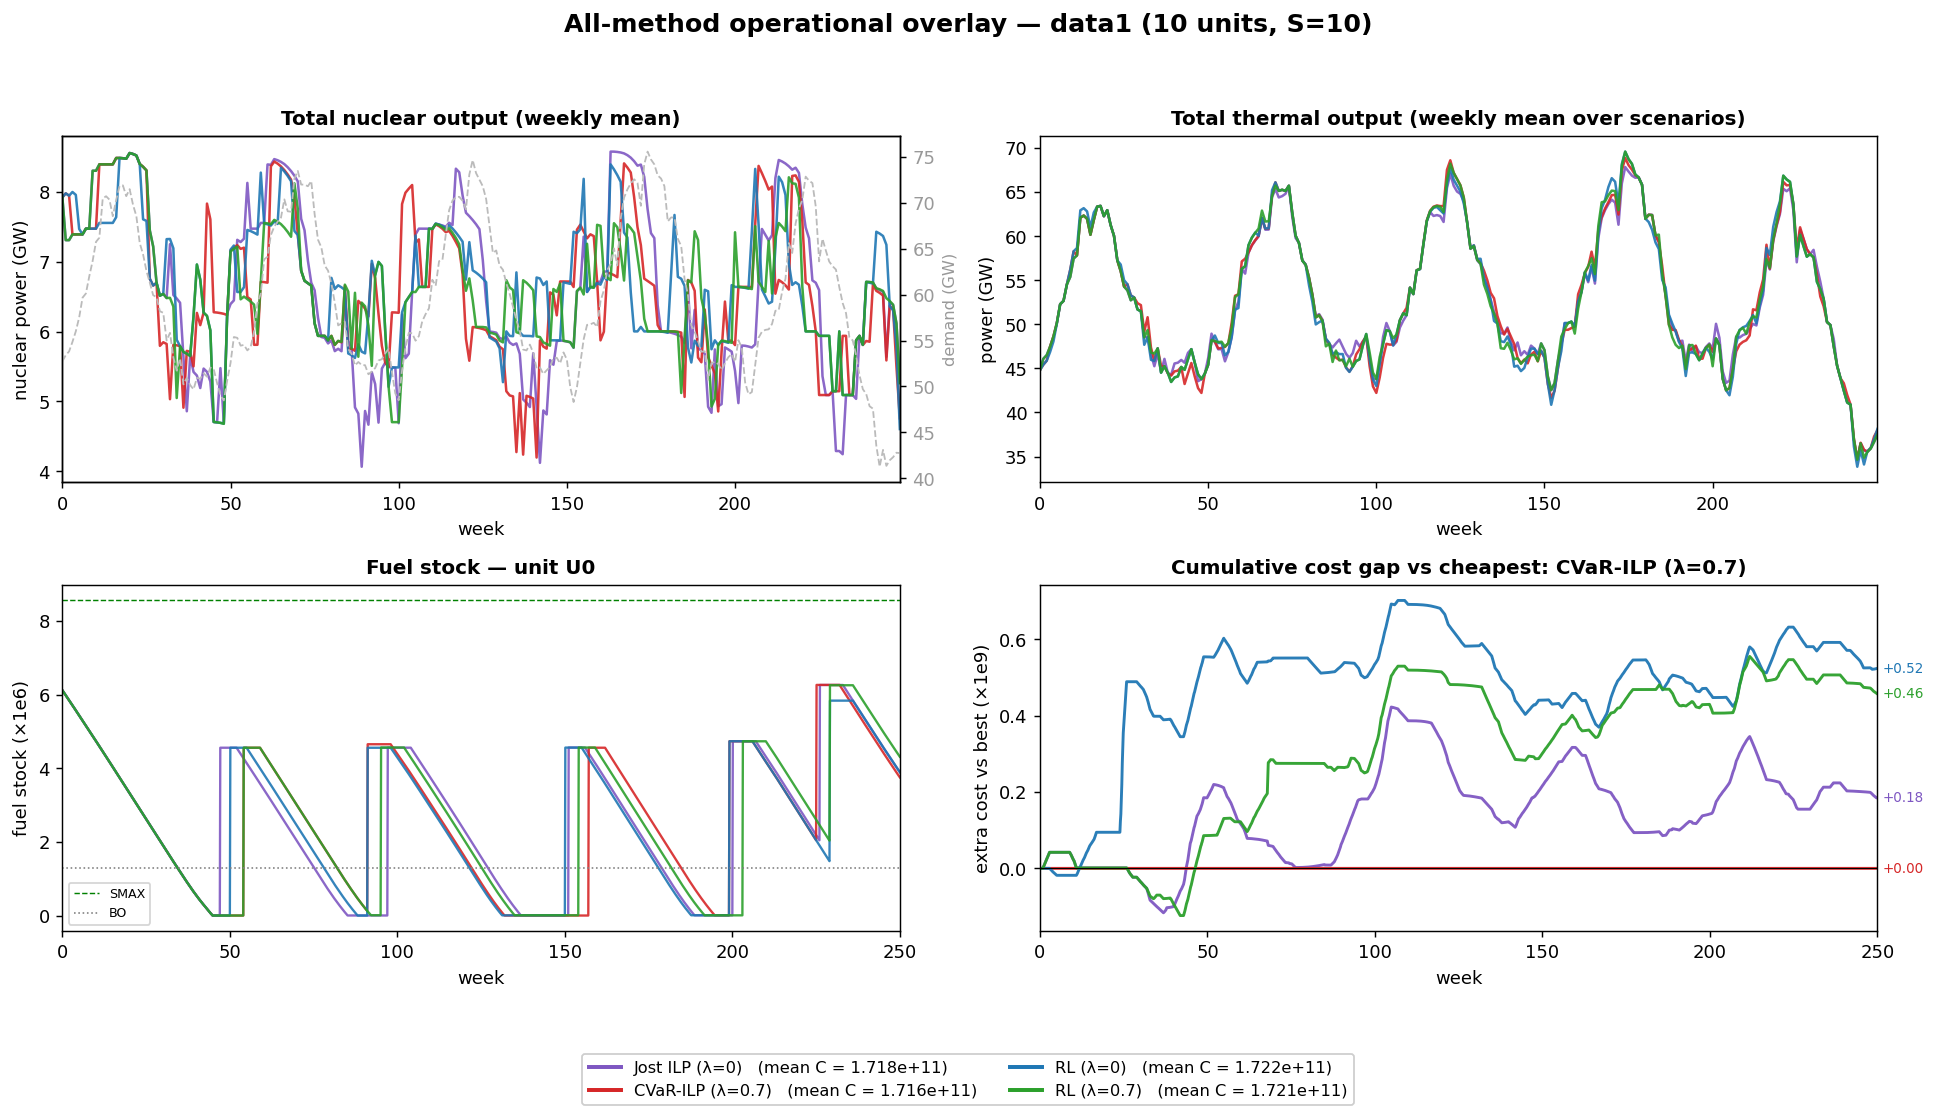

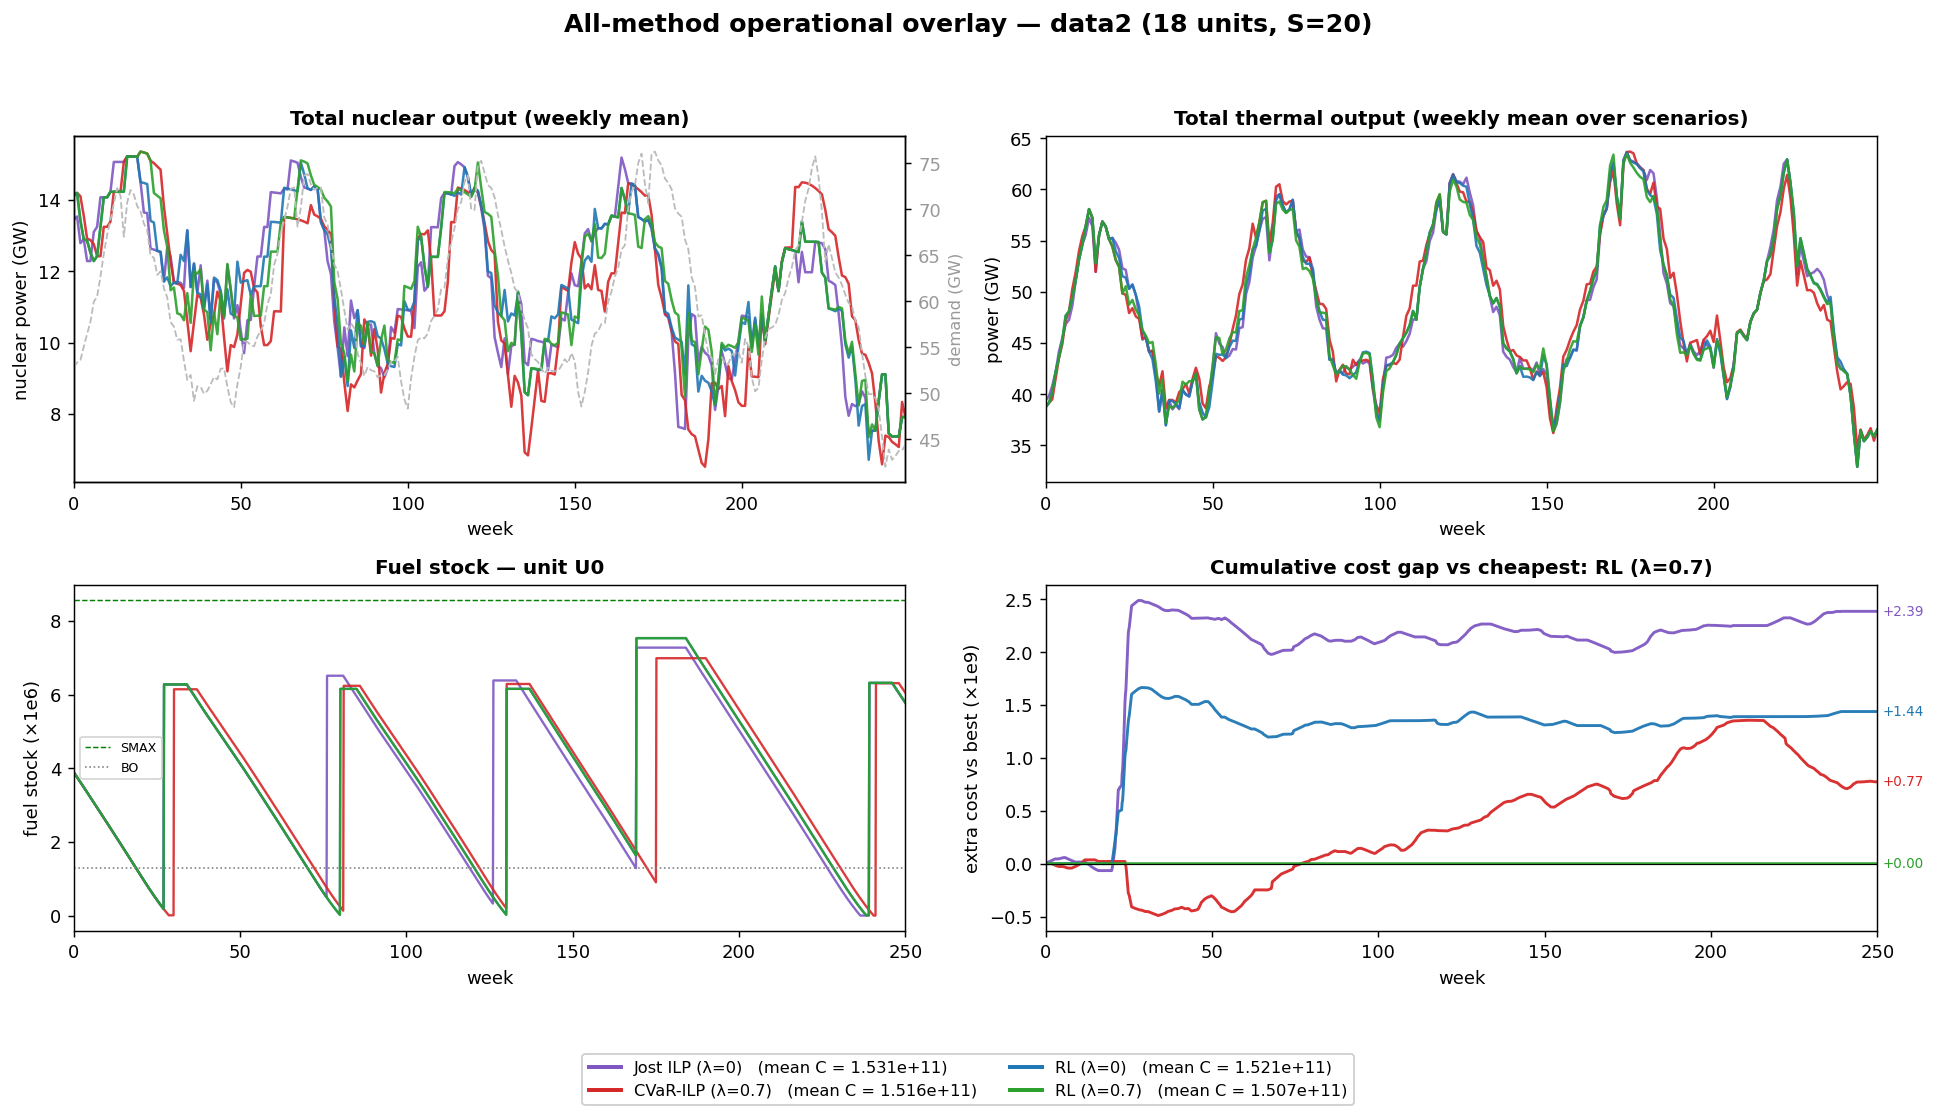

In [15]:
def operational_overlay(ds, unit=0):
    inst = INST[ds]; tpw, T, S = inst["tpw"], inst["T"], inst["S"]
    D = np.array(inst["D"]); COST = np.array([p["cost_sc"] for p in inst["type1"]])
    present = [m for m in ORDER if m in SCHED[ds]]
    data = {}
    for m in present:
        sims, p1, c = simulate(inst, *SCHED[ds][m])
        nuc = np.sum([np.asarray(sims[i][0]) for i in sims], axis=0)
        therm = p1.sum(axis=0).mean(axis=0)
        te = (COST * p1 * D[None, None, :]).sum(axis=0).mean(axis=0)
        data[m] = dict(nuc=nuc, therm=therm, cum=np.cumsum(te), fuel=np.asarray(sims[unit][1]), mean=c.mean())
    nW = T // tpw; wk = np.arange(nW)
    demand_w = figs._weekly(np.asarray(inst["DEM"]).mean(axis=0), tpw)
    p0 = {p["index"]: p for p in inst["type2"]}[unit]

    fig, ax = plt.subplots(2, 2, figsize=(15, 8.5))
    fig.suptitle(f"All-method operational overlay — {ds} ({inst['I']} units, S={S})",
                 fontsize=14, weight="bold")
    a = ax[0, 0]
    for m in present:
        a.plot(wk, figs._weekly(data[m]["nuc"], tpw) / 1e3, color=COL[m], lw=1.4, alpha=0.9)
    a.set_title("Total nuclear output (weekly mean)", fontsize=11, weight="bold")
    a.set_xlabel("week"); a.set_ylabel("nuclear power (GW)"); a.set_xlim(0, nW - 1)
    ad = a.twinx(); ad.plot(wk, demand_w / 1e3, color="#bbb", lw=1.0, ls="--")
    ad.set_ylabel("demand (GW)", color="#999", fontsize=9); ad.tick_params(axis="y", labelcolor="#999")

    a = ax[0, 1]
    for m in present:
        a.plot(wk, figs._weekly(data[m]["therm"], tpw) / 1e3, color=COL[m], lw=1.4, alpha=0.9)
    a.set_title("Total thermal output (weekly mean over scenarios)", fontsize=11, weight="bold")
    a.set_xlabel("week"); a.set_ylabel("power (GW)"); a.set_xlim(0, nW - 1)

    a = ax[1, 0]; wf = np.arange(T + 1) / tpw
    for m in present:
        a.plot(wf, data[m]["fuel"] / 1e6, color=COL[m], lw=1.3, alpha=0.9)
    a.axhline(max(p0["SMAX"]) / 1e6, ls="--", lw=0.8, color="green", label="SMAX")
    a.axhline(np.mean(p0["BO"]) / 1e6, ls=":", lw=0.9, color="grey", label="BO")
    a.set_title(f"Fuel stock — unit U{unit}", fontsize=11, weight="bold")
    a.set_xlabel("week"); a.set_ylabel("fuel stock (×1e6)"); a.set_xlim(0, T / tpw); a.legend(fontsize=7)

    a = ax[1, 1]; wt = np.arange(T) / tpw
    ref_m = min(present, key=lambda m: data[m]["cum"][-1]); ref = data[ref_m]["cum"]
    for m in present:
        gap = (data[m]["cum"] - ref) / 1e9
        a.plot(wt, gap, color=COL[m], lw=1.6, alpha=0.95)
        a.annotate(f"{gap[-1]:+.2f}", (wt[-1], gap[-1]), textcoords="offset points",
                   xytext=(3, 0), ha="left", va="center", fontsize=7.5, color=COL[m])
    a.axhline(0, color="k", lw=0.6)
    a.set_title(f"Cumulative cost gap vs cheapest: {ref_m}", fontsize=11, weight="bold")
    a.set_xlabel("week"); a.set_ylabel("extra cost vs best (×1e9)"); a.set_xlim(0, T / tpw); a.margins(x=0.08)

    handles = [Line2D([0], [0], color=COL[m], lw=2.2, label=f"{m}   (mean C = {data[m]['mean']:.3e})")
               for m in present]
    fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 0.045), framealpha=0.95)
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    path = f"fig_overlay_models_{ds}.png"; fig.savefig(path, dpi=130, bbox_inches="tight"); plt.close(fig)
    return path

for ds in ["data1", "data2"]:
    show(operational_overlay(ds))

## 14&nbsp;&nbsp;Independent feasibility verification

Every solution above is validated by the **official ROADEF `checker.jar`** — the same
authoritative validator used in the competition — not by our own simulator. The cell
below runs it on one RL solution if Java and the checker are present (set
`RUN_CHECKER = True`). A full live re-run of the RL policy + checker is in the
companion notebook **`RL_solution_check.ipynb`**.

In [16]:
RUN_CHECKER = False        # set True locally (needs Java + CHECKER/CHECKER/checker.jar)
JAR = os.path.join("CHECKER", "CHECKER", "checker.jar")
CT = ["1","2","3-4","8","5_6","7","10_11","12","13","13bis","14","15","16","17","18","19","20","21"]

def official_check(data_path, sol_path, jar=JAR, timeout=600):
    d = tempfile.mkdtemp()
    try:
        subprocess.run(["java", "-Xmx2g", "-jar", os.path.abspath(jar),
                        "-d", os.path.abspath(data_path), "-r", os.path.abspath(sol_path)],
                       cwd=d, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, timeout=timeout)
        rep = open(os.path.join(d, "constraint_check.txt"), encoding="latin-1").read().split("REPORT")[-1]
        import re
        cons = {f"CT{l}": ("OK" if (re.search(r"Constraint" + re.escape(l) + r"\s*:([^\n]*)", rep)
                 and re.search(r"Constraint" + re.escape(l) + r"\s*:([^\n]*)", rep).group(1).strip().startswith("OK"))
                 else "VIOLATED") for l in CT}
        hard = [k for k, v in cons.items() if v != "OK" and k != "CT13bis"]
        return cons, hard
    finally:
        shutil.rmtree(d, ignore_errors=True)

if RUN_CHECKER and shutil.which("java") and os.path.exists(JAR):
    data_path = os.path.join("data_release_13102009", "data_release_13102009", "data2.txt")
    cons, hard = official_check(data_path, "sol_RLls70_data2.txt")
    print("RL (λ=0.7) on data2 — official checker:")
    print("  hard violations (excl. CT13bis):", hard or "NONE ✅")
    print("  CT13bis (final-phase, soft)     :", cons["CT13bis"])
else:
    print("checker skipped (set RUN_CHECKER=True with Java + checker.jar to validate live).")
    print("See RL_solution_check.ipynb for the full independent re-run + check.")

checker skipped (set RUN_CHECKER=True with Java + checker.jar to validate live).
See RL_solution_check.ipynb for the full independent re-run + check.


## 15&nbsp;&nbsp;Summary

Across data0–data2 the local-search RL is **competitive with the integer program
everywhere and best on the largest instance (data2)**, and the risk-averse policy
($\lambda=0.7$) consistently lowers the cost tail relative to the risk-neutral one.
The absolute gaps are small (within ~2%): the nuclear fleet supplies only a fraction
of demand, so the schedule has limited leverage and the contest is decided within
that margin. This supports using RL as a flexible, uncertainty-aware **refinement of
an integer-programming seed** rather than a replacement for it.